In [1]:
import torch
import torchvision



/Users/bimladanu/.pyenv/versions/3.11.3/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Disabling PyTorch because PyTorch >= 2.4 is required but found 2.1.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
print(torch.__version__)
print(torchvision.__version__)

2.1.2
0.16.2


### CNN Image Reconstruction MNIST Datasets (with Noise + Visualization)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:10<00:00, 974478.82it/s] 


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 174038.54it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:03<00:00, 444714.91it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 1672859.92it/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

Epoch 1/5, Loss: 0.0147
Epoch 2/5, Loss: 0.0138
Epoch 3/5, Loss: 0.0139
Epoch 4/5, Loss: 0.0145
Epoch 5/5, Loss: 0.0138


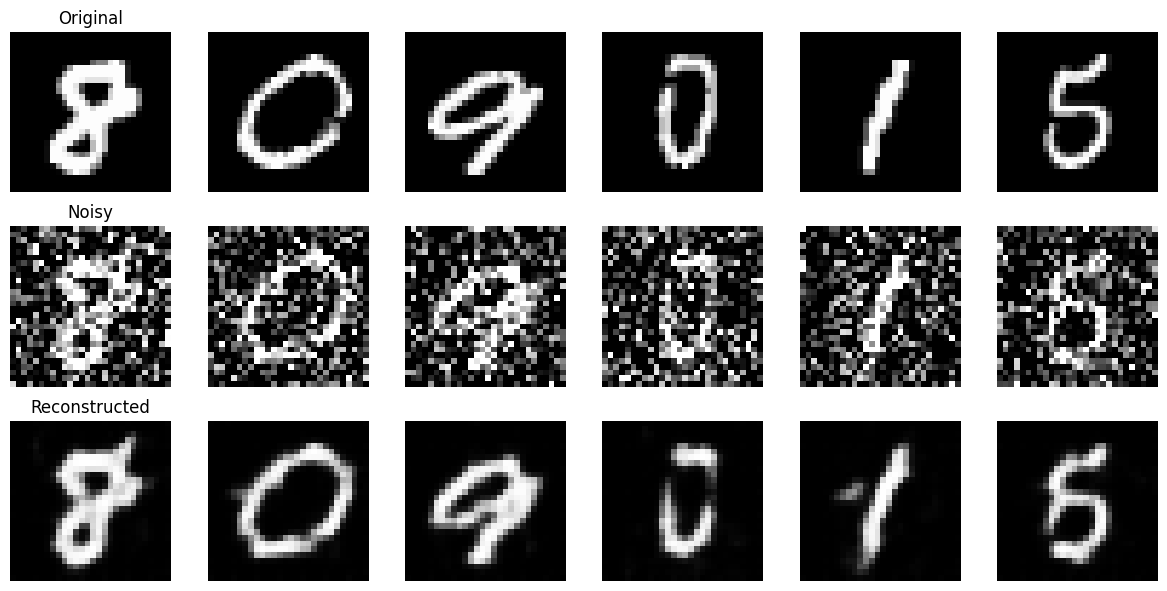

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ---------
# 1. Data
# ---------
transform = transforms.ToTensor()

dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

# ---------
# 2. Model (Autoencoder)
# ---------
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU()
        )
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.decoder(self.encoder(x))

model = Autoencoder()

# ---------
# 3. Noise function
# ---------
def add_noise(x):
    noise = torch.randn_like(x) * 0.5
    return torch.clamp(x + noise, 0., 1.)

# ---------
# 4. Training
# ---------
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 5

for epoch in range(epochs):
    for img, _ in loader:
        noisy = add_noise(img)
        output = model(noisy)
        loss = criterion(output, img)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

# ---------
# 5. Visualization
# ---------
dataiter = iter(loader)
images, _ = next(dataiter)

images = images[:6]
noisy_images = add_noise(images)

with torch.no_grad():
    outputs = model(noisy_images)

fig, axes = plt.subplots(3, 6, figsize=(12, 6))

for i in range(6):
    # Original
    axes[0, i].imshow(images[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')

    # Noisy
    axes[1, i].imshow(noisy_images[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')

    # Reconstructed
    axes[2, i].imshow(outputs[i].squeeze(), cmap='gray')
    axes[2, i].axis('off')

axes[0, 0].set_title("Original")
axes[1, 0].set_title("Noisy")
axes[2, 0].set_title("Reconstructed")

plt.tight_layout()
plt.show()

### CIFAR-10 CNN CLASSIFICATION 

100%|██████████| 170498071/170498071 [02:52<00:00, 986991.85it/s] 


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified
Epoch 1/5, Loss: 1071.1830
Epoch 2/5, Loss: 718.7078
Epoch 3/5, Loss: 572.2992
Epoch 4/5, Loss: 473.7438
Epoch 5/5, Loss: 388.7644
Test Accuracy: 74.59%


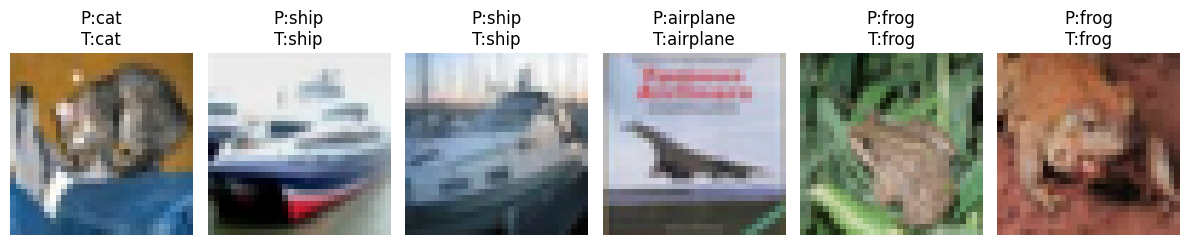

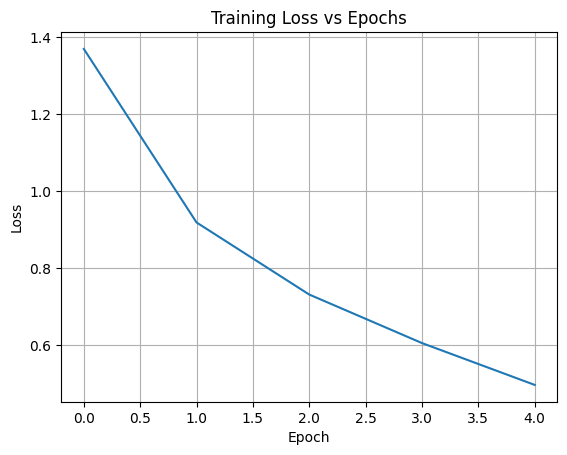

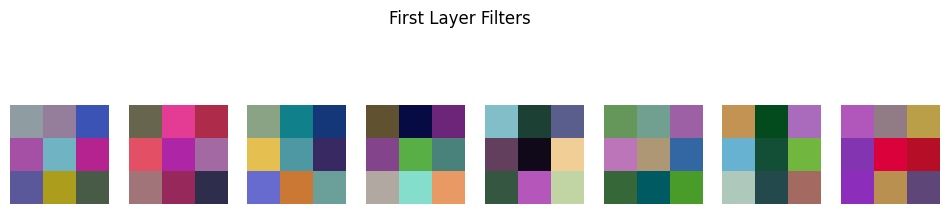

In [4]:
# ===== CIFAR-10 CNN CLASSIFICATION  WITH NORMALIZATION =====

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

def plot_loss(loss_history):
    plt.figure()
    plt.plot(loss_history)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss vs Epochs")
    plt.grid()
    plt.show()
    
    
def visualize_filters(model):
    filters = model.conv[0].weight.data.clone()

    # normalize filters to [0,1] for display
    filters = (filters - filters.min()) / (filters.max() - filters.min())

    num_filters = filters.shape[0]

    fig, axes = plt.subplots(1, min(num_filters, 8), figsize=(12, 3))

    for i in range(min(num_filters, 8)):
        f = filters[i]

        # convert CHW → HWC
        f = f.permute(1, 2, 0)

        axes[i].imshow(f)
        axes[i].axis('off')

    plt.suptitle("First Layer Filters")
    plt.show()
    
# ---------
# 1. Data (WITH NORMALIZATION)
# ---------
transform = transforms.Compose([
    transforms.ToTensor(),                         # convert image to tensor [0,1]
    transforms.Normalize((0.5, 0.5, 0.5),          # normalize mean
                         (0.5, 0.5, 0.5))          # normalize std
])

train_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_dataset  = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

# ---------
# 2. Model
# ---------
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )
    
    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

model = CNN()

# ---------
# 3. Training
# ---------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 5
loss_history = []
for epoch in range(epochs):
    total_loss = 0
    
    for img, label in train_loader:
        output = model(img)
        loss = criterion(output, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        
    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")

# ---------
# 4. Evaluation
# ---------
correct = 0
total = 0

with torch.no_grad():
    for img, label in test_loader:
        output = model(img)
        _, predicted = torch.max(output, 1)

        total += label.size(0)
        correct += (predicted == label).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

# ---------
# 5. Visualization 
# ---------
def unnormalize(img):
    img = img * 0.5 + 0.5   # reverse normalization
    return img

dataiter = iter(test_loader)
images, labels = next(dataiter)

images = images[:6]
labels = labels[:6]

with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

fig, axes = plt.subplots(1, 6, figsize=(12, 3))

for i in range(6):
    img = unnormalize(images[i])           # unnormalize before display
    img = img.permute(1, 2, 0)             # CHW → HWC

    axes[i].imshow(img)
    axes[i].set_title(f"P:{classes[preds[i]]}\nT:{classes[labels[i]]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()
#
#
plot_loss(loss_history)
visualize_filters(model)
